In [1]:
import sys
from pathlib import Path
# Make the repo root importable regardless of CWD or machine: walk up from the
# working dir until we hit a repo marker, then put that dir on sys.path.
_start = Path.cwd()
_root = next((p for p in (_start, *_start.parents)
              if (p / ".git").exists() or (p / "setup.py").exists()), _start)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
from metab_processing.metab_travlr_config import DATA_DIR


PROJECT = 'Alexi_UC_Spliced'
PROJECT_DIR = f'{DATA_DIR}/{PROJECT}'

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# --- Sample registry & shared helpers ----------------------------------------
# Every spacetravlr adata we can work with: sample name -> dataset folder under
# PROJECT_DIR (each holds spacetravlr_adata.h5ad + easy_download/...). Add rows to
# bring in more samples. `SAMPLE` (next cell) picks the one the single-sample cells
# use; the multi-sample plots at the bottom iterate all of SAMPLES.
SAMPLES = {
    'Slice 1': '13473_HS4_UC-Slice_1',
    'Slice 2': '13473_HS4_UC-Slice_2',
    'Slice 3': '13473_HS4_UC-Slice_3',
    'Slice 4': '13473_HS4_UC-Slice_4',
}


def sample_dir(sample):
    """Absolute data dir for a registered sample name."""
    return f'{PROJECT_DIR}/{SAMPLES[sample]}'


def load_sample_adata(sample):
    """Read a sample's spacetravlr adata and stamp its name onto uns['sample']
    (so chart titles can show which sample they came from)."""
    ad = sc.read_h5ad(f'{sample_dir(sample)}/spacetravlr_adata.h5ad')
    ad.uns['sample'] = sample
    return ad


def _mod_index(names, name):
    """Column index of `name` in a modulator-name array. Raises (does NOT silently
    return 0) if `name` is absent -- catches typos like 'Fatty Acid' vs 'Fatty acid'."""
    names = list(names)
    if name not in names:
        raise KeyError(f"{name!r} not found among {len(names)} modulators; e.g. {names[:6]}")
    return names.index(name)


def _ct_label(cell_types):
    """Readable cell-type tag for chart titles."""
    return 'all cells' if cell_types is None else ', '.join(cell_types)

In [3]:
# This is for loading the coefficients into the adata, which requires spacetravlr to be installed (or at least some of its required arrays)

# adata = sc.read_h5ad(f'{DATA_DIR}/adata.h5ad')
# adata

# from metab_processing.SpaceTravLR import beta_analysis

# betadata_dir = f'{DATA_DIR}/spacetravlr_output/betadata'
# beta_analysis.betas_to_adata(adata, betadata_dir, group=None)
# print(adata)
# adata.write_h5ad(f"{DATA_DIR}/spacetravlr_adata.h5ad")
# del adata

In [4]:
# --- Pick the sample the single-sample cells below work on --------------------
SAMPLE = 'Slice 1'                 # <- any key in SAMPLES (registry above)
DATASET_NAME = SAMPLES[SAMPLE]
DATA_DIR = sample_dir(SAMPLE)
adata = load_sample_adata(SAMPLE)
print(f'Loaded {SAMPLE}  ({DATASET_NAME}):', adata.shape)
adata

AnnData object with n_obs × n_vars = 12142 × 4736
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'orientation_cores', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'leiden', 'leiden_res_1_5', 'leiden_res_1_3', 'leiden_res_1_4', 'leiden_res_1_6', 'leiden_res_1_2', '25_06_11_ICI_5K_Compartments', '24_11_12_ICI_5K_Fine_annotations', '25_06_11_ICI_5K_Coarse_annotations', '240927_Condition', '25_06_11_Patient_ID_HS', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_c

/tmp/ipykernel_3591160/3727956402.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='25_06_11_ICI_5K_Coarse_annotations');


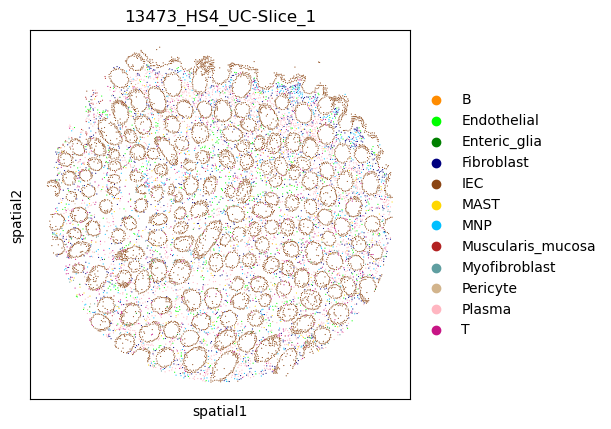

In [5]:
sc.pl.spatial(adata, spot_size=5, show=False, title=f'{SAMPLE} ({DATASET_NAME})', color='25_06_11_ICI_5K_Coarse_annotations');

In [6]:
list(adata.uns['beta_modulators'])

['ATP1A1',
 'CD3E',
 'CD3G',
 'CD4',
 'CSF2',
 'CTLA4',
 'ENTPD1',
 'FOXP3',
 'HAVCR2',
 'HIF1A',
 'IL10',
 'IL17A',
 'IL17F',
 'IL23R',
 'IL2RA',
 'LAG3',
 'MAPK11',
 'MAPK12',
 'MAPK14',
 'MYC',
 'NDRG1',
 'PDCD1',
 'RORC',
 'SCNN1A',
 'SCNN1G',
 'SGK1',
 'SLC5A1',
 'SLC9A3',
 'TBP',
 'TCF7',
 'TOX']

In [7]:
GENE = 'NDRG1'
# GENE = 'RORC'
adata.uns['beta_modulators'][GENE]

array(['AHR', 'AHRR', 'ARNT', 'ATF3', 'ATF4', 'BATF', 'BCL3', 'CREB1',
       'CTCF', 'CTCFL', 'E2F1', 'E2F3', 'E2F4', 'EGR2', 'EHF', 'ELK1',
       'ELK3', 'ELK4', 'EP300', 'ERG', 'ETS1', 'ETV1', 'ETV5', 'ETV6',
       'FEV', 'FLI1', 'FOSL1', 'FOXA1', 'FOXA2', 'FOXC1', 'FOXC2',
       'FOXE1', 'FOXE3', 'FOXI1', 'FOXJ2', 'FOXL2', 'FOXO1', 'FOXO3',
       'FOXO4', 'FOXP1', 'FOXP2', 'FOXP3', 'FOXP4', 'GATA1', 'GATA2',
       'HDAC2', 'HES1', 'HES4', 'HMGN3', 'HNF4A', 'IRF1', 'IRF4', 'JDP2',
       'JUN', 'KLF12', 'KLF14', 'KLF16', 'KLF4', 'KLF5', 'MAX', 'MEF2A',
       'MEF2C', 'NANOG', 'NFATC1', 'NFKB1', 'NR1I2', 'NR1I3', 'NR3C1',
       'NRF1', 'PAX1', 'PAX2', 'PAX5', 'PAX8', 'PBX3', 'POU5F1', 'PRDM1',
       'REST', 'RXRA', 'SALL4', 'SETDB1', 'SIN3A', 'SMAD1', 'SMARCA5',
       'SMARCB1', 'SMARCC1', 'SMC3', 'SOX18', 'SP1', 'SP3', 'SRF',
       'STAT1', 'STAT2', 'STAT3', 'TAF1', 'TAL1', 'TBP', 'TCF7L2',
       'TFAP2A', 'TFAP2B', 'TRIM28', 'TWIST1', 'TWIST2', 'WT1', 'YY1',
       'ZBTB

In [8]:
# beta * x for the metabolite modulators. `x` is the per-cell communication score the model
# multiplies each metab beta by; the pipeline saves it (shared across genes) in
# adata.obsm['x_metab'] with labels in adata.uns['x_metab_modulators'] (re-run run_spacetravlr's
# artifacts stage if this adata predates that). We line each gene's metab@<name> beta column up
# with its x column and multiply -> adata.obsm['betax_<gene>'] (cells x that gene's metabolites),
# names in adata.uns['betax_modulators'][gene], mirroring the beta_<gene> layout. tf/lr/ltf
# modulators have no saved x and are skipped.
def add_betax(adata, gene=None):
    assert 'x_metab' in adata.obsm, (
        "adata.obsm['x_metab'] not found -- re-run the run_spacetravlr artifacts stage so it "
        "saves the metabolite communication scores alongside the betas.")
    x = adata.obsm['x_metab']
    x_idx = {m: i for i, m in enumerate(adata.uns['x_metab_modulators'])}
    betax_mods = adata.uns.setdefault('betax_modulators', {})

    genes = list(adata.uns['beta_modulators']) if gene is None else [gene]
    for g in genes:
        mods = list(adata.uns['beta_modulators'][g])
        beta = adata.obsm[f'beta_{g}']
        cols, names = [], []
        for j, m in enumerate(mods):
            if m in x_idx:
                cols.append(beta[:, j] * x[:, x_idx[m]])
                names.append(m)
        adata.obsm[f'betax_{g}'] = (np.column_stack(cols) if cols
                                    else np.empty((adata.n_obs, 0), dtype=beta.dtype))
        betax_mods[g] = names
    return adata


def get_betax_modulator(adata, gene, modulator, tier=None, cell_types=None):
    """beta*x for one metabolite, mirroring get_betas_modulator."""
    i = _mod_index(adata.uns['betax_modulators'][gene], modulator)
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    return sub.obsm[f'betax_{gene}'][:, i]


add_betax(adata, GENE)

for gene in list(adata.uns['beta_modulators']):
    add_betax(adata, gene)
print(f'betax_{GENE}:', adata.obsm[f'betax_{GENE}'].shape,
      f'({len(adata.uns["betax_modulators"][GENE])} metabolites)')

betax_NDRG1: (12142, 39) (39 metabolites)


In [9]:
def plot_beta(adata, gene, modulator, tier, cell_types=None, spot_size=35):
    i = _mod_index(adata.uns['beta_modulators'][gene], modulator)
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    sub.obs['beta'] = sub.obsm[f'beta_{gene}'][:, i]
    sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
                  title=f"{adata.uns.get('sample','')} | {gene} ~ {modulator} | {_ct_label(cell_types)}")

/tmp/ipykernel_3591160/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_3591160/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_3591160/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_3591160/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,


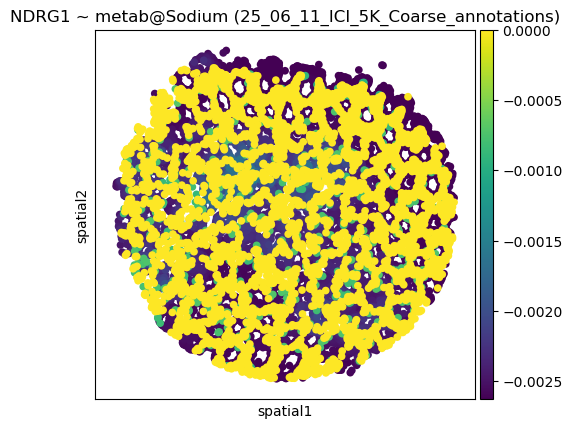

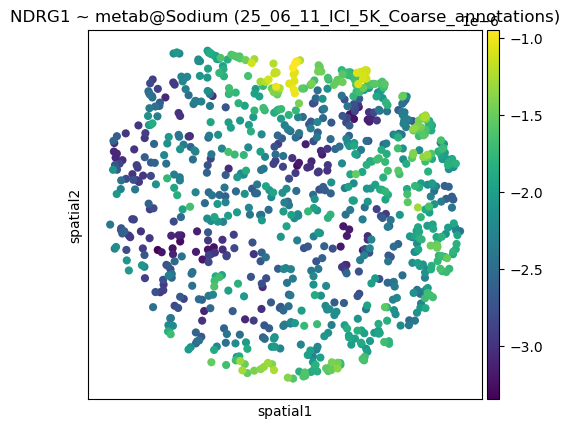

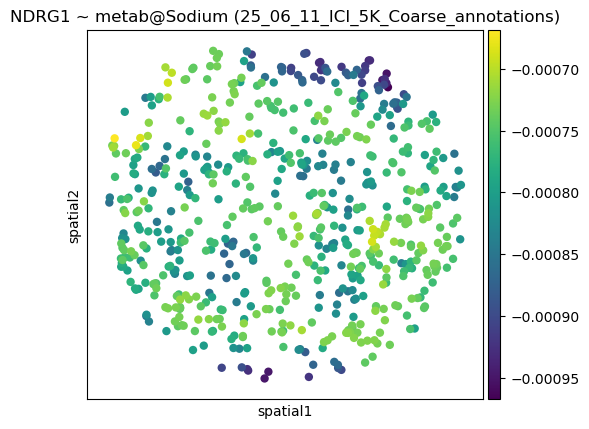

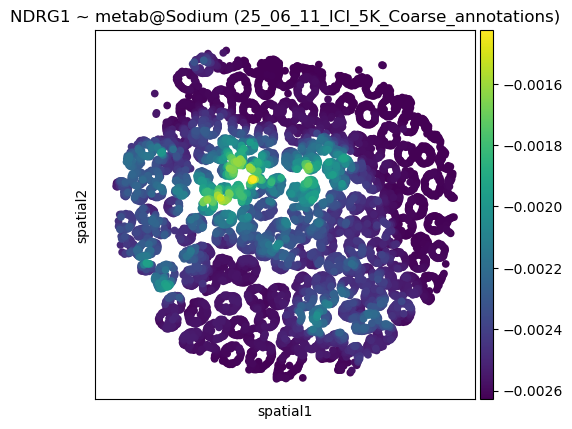

In [10]:
# gp = [m for m in adata.uns['beta_modulators'][GENE] if '@' in m][1]
gp = 'metab@Sodium'
plot_beta(adata, GENE, gp, '25_06_11_ICI_5K_Coarse_annotations')
plot_beta(adata, GENE, gp, '25_06_11_ICI_5K_Coarse_annotations', ['Fibroblast'])
plot_beta(adata, GENE, gp, '25_06_11_ICI_5K_Coarse_annotations', ['T'])
plot_beta(adata, GENE, gp, '25_06_11_ICI_5K_Coarse_annotations', ['IEC'])

In [11]:
# Same spatial plot as plot_beta, but for the metabolite x (communication score) and for
# beta * x. Requires the re-run adata (obsm['x_metab'] + add_betax already applied).
def plot_x(adata, modulator, tier, cell_types=None, spot_size=35):
    i = _mod_index(adata.uns['x_metab_modulators'], modulator)
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    sub.obs['x'] = sub.obsm['x_metab'][:, i]
    sc.pl.spatial(sub, color='x', spot_size=spot_size, show=False,
                  title=f"{adata.uns.get('sample','')} | x ~ {modulator} | {_ct_label(cell_types)}")


def plot_betax(adata, gene, modulator, tier, cell_types=None, spot_size=35):
    i = _mod_index(adata.uns['betax_modulators'][gene], modulator)
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    sub.obs['betax'] = sub.obsm[f'betax_{gene}'][:, i]
    sc.pl.spatial(sub, color='betax', spot_size=spot_size, show=False,
                  title=f"{adata.uns.get('sample','')} | {gene} ~ {modulator} beta*x | {_ct_label(cell_types)}")

/tmp/ipykernel_3591160/900847159.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='x', spot_size=spot_size, show=False,
/tmp/ipykernel_3591160/900847159.py:17: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='betax', spot_size=spot_size, show=False,


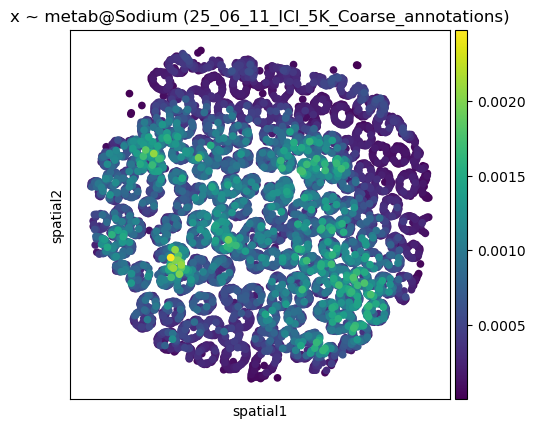

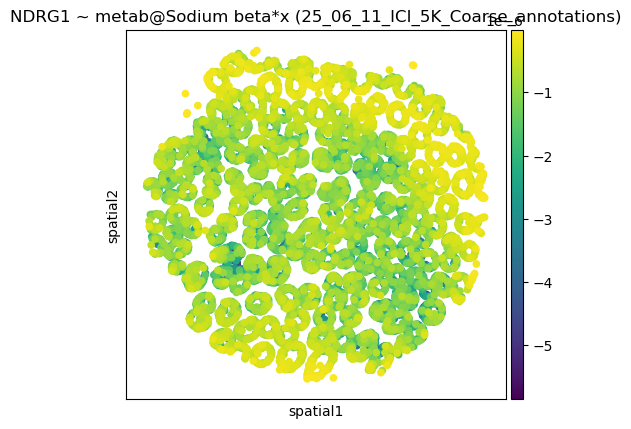

In [12]:
plot_x(adata, 'metab@Sodium', '25_06_11_ICI_5K_Coarse_annotations', cell_types=['IEC'])
plot_betax(adata, GENE, 'metab@Sodium', '25_06_11_ICI_5K_Coarse_annotations', cell_types=['IEC'])

In [13]:
adata.obsm['x_metab']

array([[3.49232932e-09, 1.31247566e-07, 5.63879888e-07, ...,
        7.01617259e-10, 5.23616183e-08, 8.31320585e-07],
       [2.77341085e-09, 4.55709866e-07, 9.21364815e-07, ...,
        1.06642711e-07, 8.40507245e-08, 4.39945527e-07],
       [4.34560952e-07, 0.00000000e+00, 0.00000000e+00, ...,
        2.53811893e-07, 6.89400485e-07, 5.68814321e-07],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.17865985e-07, 0.00000000e+00, 3.48581040e-07],
       [2.20827301e-08, 7.17380916e-08, 9.34679442e-08, ...,
        1.45943609e-07, 1.86452198e-07, 6.38624056e-07],
       [1.19960598e-07, 4.24237316e-08, 5.26219312e-08, ...,
        6.71032158e-07, 5.58581517e-08, 3.81153459e-07]],
      shape=(12142, 41))

In [14]:
def get_betas_modulator(adata, gene, modulator, tier=None, cell_types=None):
    i = _mod_index(adata.uns['beta_modulators'][gene], modulator)
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    return sub.obsm[f'beta_{gene}'][:, i]

def agg_modulator(adata, gene, modulator, tier=None, cell_types=None):
    betas = get_betas_modulator(adata, gene, modulator, tier, cell_types)
    return np.mean(betas), np.std(betas)

agg_modulator(adata, GENE, 'NFKB1', '25_06_11_ICI_5K_Coarse_annotations', cell_types=['IEC'])
        

(np.float32(0.22868206), np.float32(0.15449575))

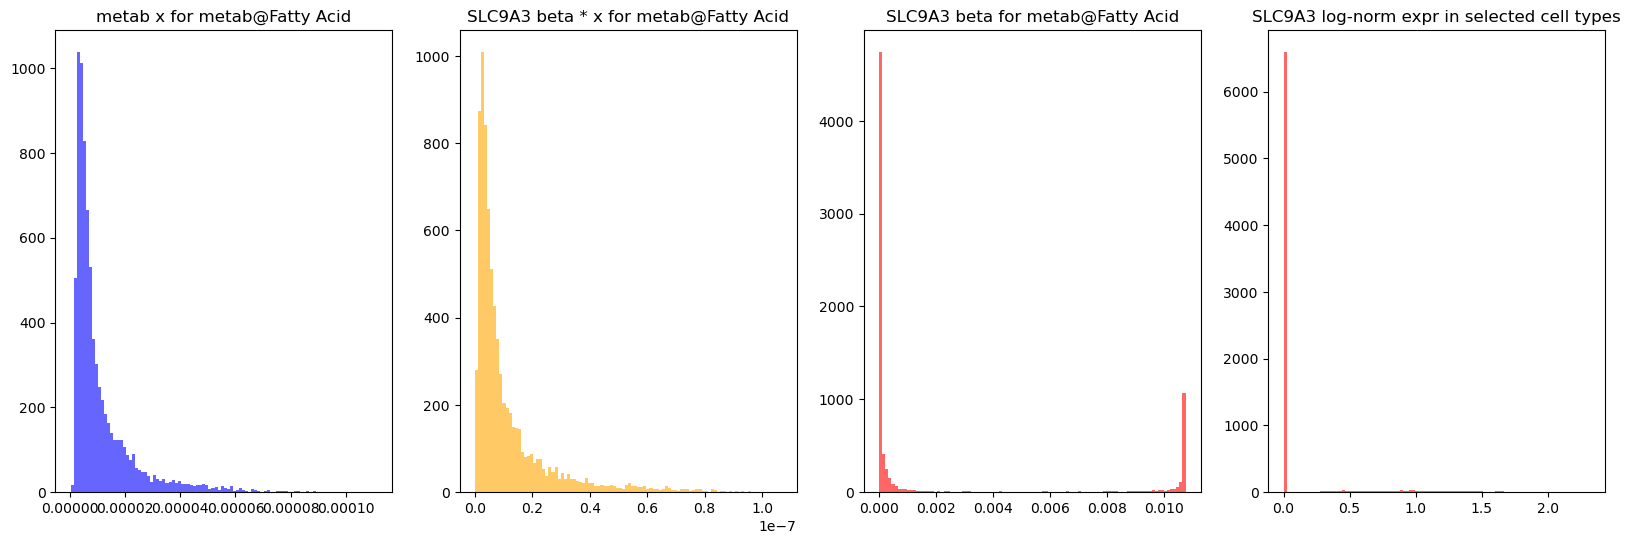

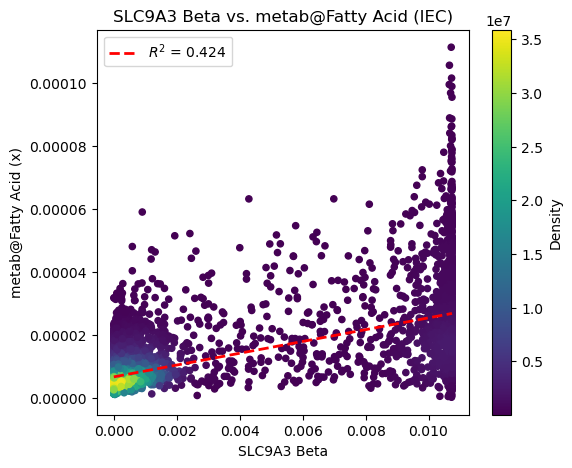

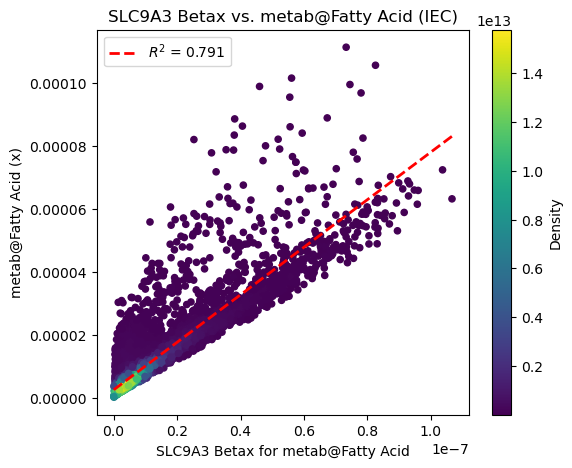

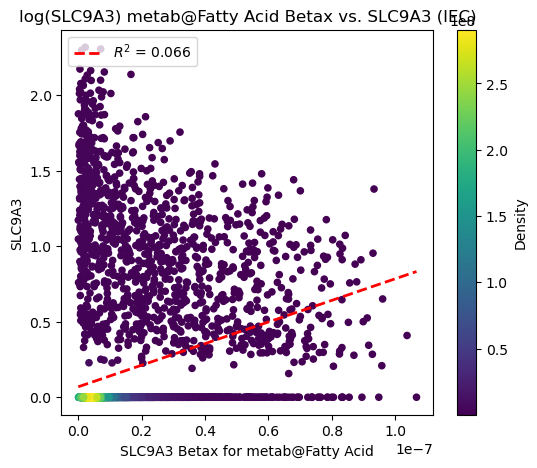

In [15]:
from scipy.stats import gaussian_kde
from scipy.stats import linregress

MY_CELL_TYPE = 'IEC'
MY_GENE = 'NDRG1'
# MY_GENE = 'RORC'
# MY_GENE = 'MYC'
# MY_GENE = 'SCNN1A'
# MY_GENE = 'CD3E'
MY_GENE = 'SLC9A3'
MY_METAB = 'metab@Sodium'
# MY_METAB = 'metab@Water'
MY_METAB = 'metab@Fatty acid'


def get_metab_x_modulator(adata, modulator, tier, cell_types=None):
    i = _mod_index(adata.uns['x_metab_modulators'], modulator)
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    return sub.obsm['x_metab'][:, i]

def get_betax_modulator(adata, gene, modulator, tier, cell_types=None):
    i = _mod_index(adata.uns['betax_modulators'][gene], modulator)
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    return sub.obsm[f'betax_{gene}'][:, i]

# Fetch the data
data_beta = get_betas_modulator(adata, MY_GENE, MY_METAB, '25_06_11_ICI_5K_Coarse_annotations', cell_types=[MY_CELL_TYPE])
data_metab = get_metab_x_modulator(adata, MY_METAB, '25_06_11_ICI_5K_Coarse_annotations', cell_types=[MY_CELL_TYPE])
data_betax = get_betax_modulator(adata, MY_GENE, MY_METAB, '25_06_11_ICI_5K_Coarse_annotations', cell_types=[MY_CELL_TYPE])
data_target = adata[adata.obs['25_06_11_ICI_5K_Coarse_annotations'] == MY_CELL_TYPE][:, MY_GENE].layers['log_normalized_counts'].toarray().flatten()  # adata.X is raw counts

# Plot side-by-side
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 6))

ax1.hist(data_metab, alpha=0.6, color='blue', bins=100)
ax1.set_title(f'metab x for {MY_METAB}')

ax2.hist(data_betax, alpha=0.6, color='orange', bins=100)
ax2.set_title(f'{MY_GENE} beta * x for {MY_METAB}')

ax3.hist(data_beta, alpha=0.6, color='red', bins=100)
ax3.set_title(f'{MY_GENE} beta for {MY_METAB}')

ax4.hist(data_target, alpha=0.6, color='red', bins=100)
ax4.set_title(f'{MY_GENE} log-norm expr in selected cell types')
fig.suptitle(f'{adata.uns.get("sample","")} \u2014 {MY_GENE} / {MY_METAB} ({MY_CELL_TYPE})')

def plot_density_scatter(x_data, y_data, xlabel="X", ylabel="Y", title="Density Scatter Plot"):
    # Flatten and filter NaNs
    x, y = np.ravel(x_data), np.ravel(y_data)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]
    
    # Calculate density
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    # Linear regression for trendline and R^2
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r_squared = r_value**2

    # Plot
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(x, y, c=z, s=20, cmap='viridis')
    
    # Trendline
    x_seq = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_seq, slope * x_seq + intercept, color='red', linestyle='--', 
            linewidth=2, label=f'$R^2$ = {r_squared:.3f}')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc='upper left')
    
    plt.colorbar(sc, ax=ax, label='Density')
    plt.show()

plot_density_scatter(
    x_data=data_beta,
    y_data=data_metab,
    xlabel=f'{MY_GENE} Beta',
    ylabel=f'{MY_METAB} (x)',
    title=f'{adata.uns.get("sample","")} | {MY_GENE} Beta vs. {MY_METAB} ({MY_CELL_TYPE})'
)

plot_density_scatter(
    x_data=data_betax,
    y_data=data_metab,
    xlabel=f'{MY_GENE} Betax for {MY_METAB}',
    ylabel=f'{MY_METAB} (x)',
    title=f'{adata.uns.get("sample","")} | {MY_GENE} Betax vs. {MY_METAB} ({MY_CELL_TYPE})'
)

plot_density_scatter(
    x_data=data_betax,
    y_data=data_target,
    xlabel=f'{MY_GENE} Betax for {MY_METAB}',
    ylabel=f'{MY_GENE}',
    title=f'{adata.uns.get("sample","")} | log({MY_GENE}) {MY_METAB} Betax vs. {MY_GENE} ({MY_CELL_TYPE})'
)

In [ ]:
# For every (target gene, metabolite) pair, the R^2 of that pair's beta*x against the gene's
# own (log-normalized) expression -- how much of the gene's expression the metabolite's
# contribution (beta*x) linearly explains, in the selected cells. Same linear fit as
# plot_density_scatter above, tabulated. adata.X is raw counts, so expression is read from
# `layer` (default 'log_normalized_counts'; pass layer=None to use .X). Extra per-pair fields:
#   avg_abs_beta -- mean |beta| (the raw coefficient, no x)
#   avg_betax    -- mean beta*x (the coefficient's actual contribution)
#   avg_expr     -- mean gene expression       (same for every metabolite of a gene)
#   var_expr     -- variance of gene expression (same for every metabolite of a gene)
# NaN betas/expression are dropped per pair; pairs with <3 valid cells or a constant beta*x /
# constant expression get NaN R^2. Metabolite columns are indexed by position (add_betax order).
def betax_vs_gene_r2(adata, tier, cell_types=None, genes=None, layer='log_normalized_counts'):
    genes = list(adata.uns['betax_modulators']) if genes is None else genes
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    rows = []
    for g in genes:
        col = sub[:, g].X if layer is None else sub[:, g].layers[layer]
        y = col.toarray().ravel()                  # gene expression over the selected cells
        avg_expr, var_expr = float(np.nanmean(y)), float(np.nanvar(y))
        beta = sub.obsm[f'beta_{g}']               # cells x all modulators (raw beta)
        beta_mods = list(adata.uns['beta_modulators'][g])
        bx = sub.obsm[f'betax_{g}']                # cells x this gene's metabolites (beta*x)
        for j, metab in enumerate(adata.uns['betax_modulators'][g]):
            x = bx[:, j]
            b = beta[:, beta_mods.index(metab)]    # raw beta for this metabolite
            m = ~np.isnan(x) & ~np.isnan(y)
            ok = m.sum() >= 3 and np.ptp(x[m]) > 0 and np.ptp(y[m]) > 0
            r2 = linregress(x[m], y[m]).rvalue ** 2 if ok else np.nan
            rows.append({'gene': g, 'metabolite': metab, 'r2': r2,
                         'avg_abs_beta': float(np.nanmean(np.abs(b))),
                         'avg_betax': float(np.nanmean(x)),
                         'avg_expr': avg_expr, 'var_expr': var_expr,
                         'n_cells': int(m.sum())})
    return pd.DataFrame(rows).sort_values('r2', ascending=False, ignore_index=True)

In [17]:
# One row per (target gene, metabolite), sorted by R^2. This is the third density scatter
# above (NDRG1 beta*x vs NDRG1) computed for every gene/metabolite pair, in IEC cells.
betax_r2 = betax_vs_gene_r2(adata, '25_06_11_ICI_5K_Coarse_annotations', cell_types=[MY_CELL_TYPE])
betax_r2.head(50)

,gene,metabolite,r2,n_cells
0,SLC9A3,metab@Anion exchange,0.645414,7778
1,SLC9A3,metab@Sodium_hydrogen exchange,0.633653,7778
2,SLC9A3,metab@4-ene-Valproic acid,0.582461,7778
3,SLC9A3,metab@Acetyl-L-Carnitine|Choline|Creatine|Dopa...,0.582157,7778
4,SLC9A3,metab@L-Carnitine,0.577309,7778
5,SLC9A3,metab@Nicotinate,0.572491,7778
6,SLC9A3,metab@Taurocholic acid,0.569918,7778
7,SLC9A3,metab@Cholic acid,0.563974,7778
8,SLC9A3,metab@O-Desmethylverapamil (D-702),0.555146,7778
9,SLC9A3,metab@Amiloride-sensitive sodium transport,0.555124,7778


In [ ]:
# Small helper: reshape the R^2 table (or any per-pair table above) into a 2-D grid of one
# field, so you can eyeball it. Default is metabolites down the rows, genes across the columns
# (gene names are short); swap index/columns to flip it.
def pivot_field(df, field='r2', index='metabolite', columns='gene'):
    return df.pivot(index=index, columns=columns, values=field)

In [ ]:
# Demo: R^2 as a gene (columns) x metabolite (rows) grid. Swap `field` for any column
# ('avg_abs_beta', 'avg_betax', 'avg_expr', 'var_expr', 'n_cells').
pivot_field(betax_r2, 'r2')

In [18]:
# Divide cells into two groups by a single (gene, metabolite) beta*x, then compare their
# gene expression. `frac` is the top-fraction cutoff: frac=0.9 -> the top 10% of cells by
# beta*x are 'high', the rest 'low'. split_cells_by_betax plots the beta*x distribution with
# the cutoff line; dge_betax_groups runs a standard Wilcoxon rank-genes test between the groups.
def split_cells_by_betax(adata, gene, metab, tier, cell_types=None, frac=0.9, plot=True):
    """Return (sub, cutoff); sub.obs['betax_group'] labels each cell 'high'/'low'."""
    mods = list(adata.uns['betax_modulators'][gene])
    if metab not in mods:                          # explicit -- avoid argmax silently picking col 0
        raise ValueError(f"{metab!r} is not a metabolite modulator of {gene}. Options: {mods}")
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    bx = sub.obsm[f'betax_{gene}'][:, mods.index(metab)]
    keep = ~np.isnan(bx)                           # drop cells with no beta*x for this pair
    sub, bx = sub[keep].copy(), bx[keep]
    assert bx.size, f"no cells left for {gene}/{metab} in {cell_types}"
    cutoff = np.quantile(bx, frac)
    n_high = int((bx >= cutoff).sum())
    if not 0 < n_high < len(bx):                   # e.g. zero-inflated beta*x -> quantile lands on 0
        raise ValueError(f"degenerate split: n_high={n_high} of {len(bx)} cells at frac={frac} "
                         f"(beta*x is likely zero-inflated here -- try a smaller frac).")
    sub.obs['betax_group'] = pd.Categorical(np.where(bx >= cutoff, 'high', 'low'),
                                            categories=['low', 'high'])
    if plot:
        plt.hist(bx, bins=100)
        plt.axvline(cutoff, color='red', ls='--',
                    label=f'top {1 - frac:.0%}  (cutoff={cutoff:.3g}, n_high={n_high})')
        plt.xlabel(f'{gene} beta*x for {metab}'); plt.ylabel('cells')
        plt.title(f'{adata.uns.get("sample","")} | {gene} ~ {metab} | {_ct_label(cell_types)}: high vs low beta*x')
        plt.legend(); plt.show()
    return sub, cutoff


def dge_betax_groups(sub, n_genes=20, layer='log_normalized_counts', method='wilcoxon'):
    """Differential expression of 'high' vs 'low' betax_group (positive score = up in 'high').
    `sub` comes from split_cells_by_betax. adata.X is raw counts, so DGE reads `layer`
    (default 'log_normalized_counts' for meaningful logfoldchanges; pass layer=None for .X).
    Returns the scanpy rank_genes_groups table (top n_genes; n_genes=None for all)."""
    sc.tl.rank_genes_groups(sub, 'betax_group', groups=['high'], reference='low',
                            method=method, layer=layer, use_raw=False)
    df = sc.get.rank_genes_groups_df(sub, group='high')
    return df if n_genes is None else df.head(n_genes)

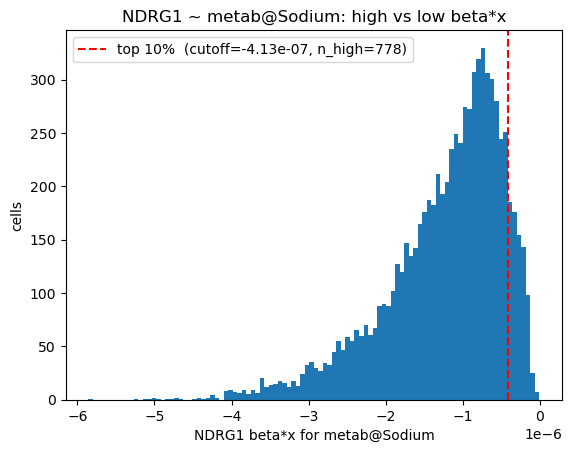

,names,scores,logfoldchanges,pvals,pvals_adj
0,FABP1,32.977730,2.549038,1.694381e-238,8.024589e-235
1,PHGR1,27.700144,1.391278,6.954437e-169,1.097874e-165
2,SLC26A2,23.159954,2.660349,1.153983e-118,1.093053e-115
3,KRT20,22.439697,2.535810,1.613412e-111,1.273520e-108
4,SLC26A3,19.158989,2.563829,8.143909e-82,5.509936e-79
5,SLC9A3,17.597961,2.406046,2.553541e-69,1.511696e-66
6,MALL,14.041297,2.564204,8.710410e-45,4.125250e-42
7,ANPEP,14.007973,0.733947,1.393253e-44,5.998586e-42
8,SELENBP1,12.283514,1.418801,1.110666e-34,3.506743e-32
9,AQP8,11.690047,1.950376,1.433073e-31,3.572123e-29


In [19]:
# Example: split IEC cells by NDRG1's beta*x for Sodium (top 10%), then DGE high vs low.
# DGE reads the log_normalized_counts layer by default (adata.X is raw counts).
grp, cutoff = split_cells_by_betax(adata, GENE, 'metab@Sodium',
                                   '25_06_11_ICI_5K_Coarse_annotations',
                                   cell_types=['IEC'], frac=0.9)
dge_betax_groups(grp, n_genes=20)

In [20]:
CELL_TYPE = 'IEC'
TIER = '25_06_11_ICI_5K_Coarse_annotations'
modulators = [x for x in adata.uns['beta_modulators'][GENE] if x.startswith('metab@')]
for modulator in modulators:
    print(modulator)

metab@(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3-yl-b-D-Glucopyranosiduronic acid|1b,3a,12a-Trihydroxy-5b-cholanoic acid|3-Sulfodeoxycholic acid|3alpha,7alpha-Dihydroxycoprostanic acid|3b-Hydroxy-5-cholenoic acid|Chenodeoxycholic acid|Chenodeoxycholic acid 3-sulfate|Coprocholic acid|Deoxycholic acid|Folinic acid|Glutathione|Glycochenodeoxycholate-3-sulfate|Hyodeoxycholic acid|Isoursodeoxycholic acid|Lithocholic acid|Sulfolithocholic acid|Trihydroxycoprostanoic acid|Ursocholic acid|Ursodeoxycholic acid|Ursodeoxycholic acid 3-sulfate|Varanic acid
metab@17a-Ethynylestradiol|3',4'-Dihydrodiol|4'-Hydroxydiclofenac|4-Hydroxycyclophosphamide|8-Hydroxycarvedilol|E-3179|Estriol|Glycerol|N-Desmethylcitalopram|N-Desmethyleletriptan|O-Deethylated candesartan
metab@2-Hydroxychlorpropamide
metab@25-Hydroxycholesterol
metab@4-ene-Valproic acid
metab@5-Hydroxyomeprazole
metab@Acetate
metab@Acetyl-L-Carnitine|Choline|Creatine|Dopamine|Histamine|Norepinephrine
metab@Adenosine triphosphate
metab@Amil

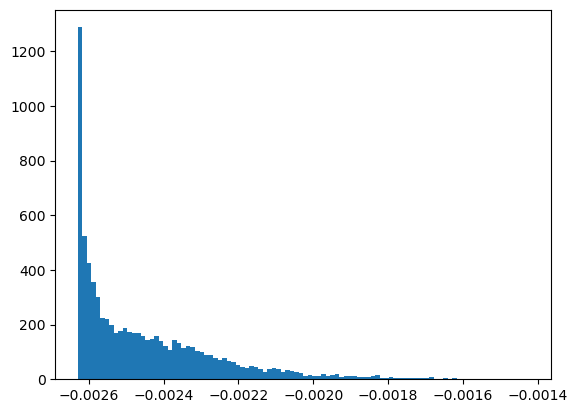

In [21]:
plt.hist(get_betas_modulator(adata, GENE, 'metab@Sodium', tier=TIER, cell_types=[CELL_TYPE]), bins=100);
# plt.hist(get_betas_modulator(adata, GENE, 'metab@Fatty Acid', tier=TIER, cell_types=[CELL_TYPE]))
# plt.hist(get_betas_modulator(adata, GENE, 'metab@Sodium', tier=TIER, cell_types=[CELL_TYPE]));
# plt.hist(get_betas_modulator(adata, GENE, 'metab@Sodium', tier=TIER, cell_types=[CELL_TYPE]));

In [22]:
harr_data_path = f'{DATA_DIR}/easy_download/harreman_outputs/[ccc_results][cell_com_df_m].csv'
harr_data = pd.read_csv(harr_data_path)
harr_data

,Unnamed: 0,Metabolite,C_p,Z,Z_pval,Z_FDR,C_np,pval_np,FDR_np,selected
0,0,"(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3...",6561.722476,3.819081,6.697476e-05,1.924002e-04,4565.770532,0.000999,0.001902,True
1,1,17a-Ethynylestradiol,1087.732313,0.863965,1.938036e-01,2.861772e-01,6204.135907,0.000999,0.001902,True
2,2,"1b,3a,12a-Trihydroxy-5b-cholanoic acid",6561.722476,3.819081,6.697476e-05,1.924002e-04,4565.770532,0.000999,0.001902,True
3,3,2-Hydroxychlorpropamide,983.805484,1.637178,5.079666e-02,9.787648e-02,8111.022841,0.000999,0.001902,True
4,4,25-Hydroxycholesterol,2345.571542,7.050788,8.895373e-13,9.369792e-12,2269.443120,0.002997,0.005571,True
...,...,...,...,...,...,...,...,...,...,...
153,153,Vitamin D3,2263.143662,6.803010,5.122786e-12,4.761178e-11,538.379201,0.000999,0.001902,True
154,154,Water,10068.549837,3.772934,8.066959e-05,2.276035e-04,130704.198027,0.000999,0.001902,True
155,155,Zinc,3985.656137,5.215775,9.152535e-08,5.561925e-07,2995.874037,0.000999,0.001902,True
156,156,alpha-Ketoisovaleric acid,1084.573588,3.260228,5.566131e-04,1.395950e-03,2595.406559,0.000999,0.001902,True


In [23]:
def _modulator_members(modulator):
    """'metab@A|B|C' -> ['A', 'B', 'C'] (exact whole-metabolite names)."""
    name = modulator.split('@', 1)[1] if '@' in modulator else modulator
    return name.split('|')


def mean_abs_coeff(adata, TARGET_GENE, modulator, tier=None, cell_types=None):
    tier = TIER if tier is None else tier
    cell_types = [CELL_TYPE] if cell_types is None else cell_types
    betas = np.nan_to_num(get_betas_modulator(adata, TARGET_GENE, modulator, tier, cell_types))
    return np.mean(np.abs(betas)), np.std(betas)


def extract_betas(TARGET_GENE, adata, harr=None, tier=None, cell_types=None):
    """One row per metabolite: avg |β|, β std, and both FDRs. Returns a DataFrame.
    harr/tier/cell_types default to the notebook globals (harr_data, TIER, CELL_TYPE); pass
    them explicitly (e.g. from plot_topk_all_samples) to run on another sample's data."""
    harr = harr_data if harr is None else harr
    modulators = adata.uns['beta_modulators'][TARGET_GENE]
    rows = []

    for metab in harr['Metabolite']:
        # EXACT membership, not substring: 'Adenosine' no longer matches
        # 'Adenosine triphosphate' or 'Adenosine diphosphate ribose'.
        match = [m for m in modulators if metab in _modulator_members(m)]

        if len(match) > 1:
            print(f"WARNING: {metab} matched multiple modulators: {match}")
            continue
        elif len(match) == 0:
            avg_coeff, std_coeff = 0.0, np.nan
        else:
            avg_coeff, std_coeff = mean_abs_coeff(adata, TARGET_GENE, match[0], tier, cell_types)

        h = harr.loc[harr['Metabolite'] == metab].iloc[0]
        rows.append({
            'metabolite': metab,
            'avg_coeff': avg_coeff,
            'std_coeff': std_coeff,
            'FDR_np': float(h['FDR_np']),
            'Z_FDR': float(h['Z_FDR']),
        })

    return pd.DataFrame(rows)


def plot_betas(df, fdr_col='Z_FDR', TARGET_GENE='', ax=None,
               labels=True, xlim=None, ylim=None):
    """Scatter avg |β| vs -log10(FDR). Set labels=False to hide text;
    pass xlim/ylim tuples to zoom."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    x = df['avg_coeff'].to_numpy()
    y = -np.log10(df[fdr_col].to_numpy())


    ax.scatter(x, y, s=30, alpha=0.8)
    ax.axhline(-np.log10(0.05), ls='--', lw=1, color='grey', label='FDR = 0.05')
    ax.axvline(0, ls=':', lw=1, color='grey')
    ax.set_xlabel('Average |modulator coefficient| (|β|)')
    ax.set_ylabel(f'-log10({fdr_col})')
    ax.set_title(f'{TARGET_GENE}: {fdr_col} vs avg |β|')
    ax.legend()

    if labels:
        for m, xi, yi in zip(df['metabolite'], x, y):
            if xi != 0:
                ax.annotate(m, (xi, yi), fontsize=7,
                            xytext=(3, 3), textcoords='offset points')

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    return ax

fdr_vs_bata_df = extract_betas('CD3E', adata)

In [24]:
def extract_betas_all(target_genes, adata):
    """{gene: DataFrame} — one extract_betas result per target gene."""
    return {gene: extract_betas(gene, adata) for gene in target_genes}


def plot_betas_grid(dfs, fdr_col='Z_FDR', labels=False, ncols=3,
                    xlim=None, ylim=None, figsize=None):
    """Plot every gene's df in a grid. `dfs` is the {gene: DataFrame} dict."""
    genes = list(dfs)
    ncols = min(ncols, len(genes))
    nrows = -(-len(genes) // ncols)  # ceil
    if figsize is None:
        figsize = (5 * ncols, 4 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    for ax, gene in zip(axes, genes):
        plot_betas(dfs[gene], fdr_col=fdr_col, TARGET_GENE=gene, ax=ax,
                   labels=labels, xlim=xlim, ylim=ylim)

    for ax in axes[len(genes):]:  # hide unused panels
        ax.axis('off')

    fig.tight_layout()
    return fig, axes

genes = list(adata.uns['beta_modulators'])
dfs = extract_betas_all(genes, adata)

In [25]:
NDRG1_df = dfs[GENE]
NDRG1_df

,metabolite,avg_coeff,std_coeff,FDR_np,Z_FDR
0,"(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3...",5.630703e-04,8.217793e-05,0.001902,1.924002e-04
1,17a-Ethynylestradiol,1.004591e-02,3.423900e-03,0.001902,2.861772e-01
2,"1b,3a,12a-Trihydroxy-5b-cholanoic acid",5.630703e-04,8.217793e-05,0.001902,1.924002e-04
3,2-Hydroxychlorpropamide,1.537748e-02,4.343918e-03,0.001902,9.787648e-02
4,25-Hydroxycholesterol,3.534478e-05,1.400429e-05,0.005571,9.369792e-12
...,...,...,...,...,...
153,Vitamin D3,0.000000e+00,NaN,0.001902,4.761178e-11
154,Water,9.532682e-01,4.156162e-01,0.001902,2.276035e-04
155,Zinc,6.212905e-08,1.572782e-08,0.001902,5.561925e-07
156,alpha-Ketoisovaleric acid,4.840450e-04,1.919141e-04,0.001902,1.395950e-03


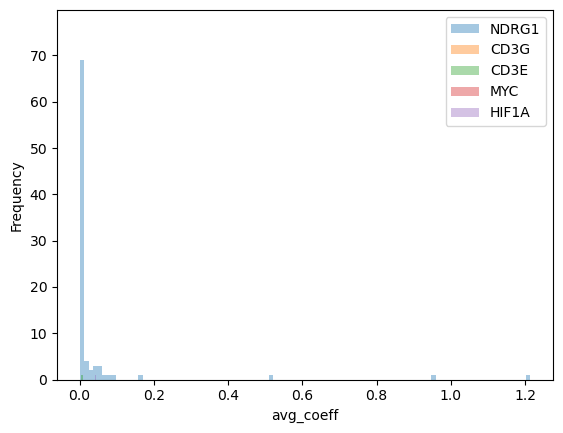

In [26]:
genes_to_plot = [GENE, 'CD3G', 'CD3E', 'MYC', 'HIF1A']

# 'negative_control': ['ACTB', 'B2M'],
#     'consistency': ['CD3D', 'CD3G', 'CD3E'],
#     'positive_control': ['MYC', 'HIF1A'],

for gene in genes_to_plot:
    # Filter out 0 values from avg_coeff
    coeffs = dfs[gene]['avg_coeff']
    non_zero_coeffs = coeffs[coeffs != 0]

    # Plot histogram
    plt.hist(non_zero_coeffs, bins=100, label=gene, alpha=0.4)

plt.legend()
plt.xlabel('avg_coeff')
plt.ylabel('Frequency')
plt.show()

In [27]:
# For each target gene: its k-th largest metabolite beta vs the variance of that gene's
# (log-normalized) expression. One point per gene. `dfs` is the extract_betas_all output above,
# so the beta used is `avg_coeff` (mean |beta| across the selected cells) per metabolite. A
# lighter, single-plot alternative to the per-gene histograms above: "do genes whose expression
# varies a lot also have a strong top metabolite coefficient?".
#   k=5          -> use the 5th largest metabolite beta (change k for 10th, etc.)
#   percentile=90 -> use the 90th-percentile beta instead (overrides k)
# adata.X is raw counts, so variance is taken on `layer` (default 'log_normalized_counts';
# layer=None uses .X). NOTE: `dfs` bakes in the cell type it was built with (extract_betas uses
# the notebook-global CELL_TYPE), so pass the SAME cell_types here, else beta_stat and variance
# come from different populations. `n_active` = metabolites with a non-zero beta for that gene.
def topk_beta_vs_variance(dfs, adata, tier, cell_types=None, k=5, percentile=None,
                          coeff_col='avg_coeff', layer='log_normalized_counts', plot=True):
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    rows = []
    for gene, df in dfs.items():
        if gene not in sub.var_names:
            continue
        c = df[coeff_col].to_numpy()
        c = c[c > 0]                      # drop metabolites with no modulator (beta == 0) for this gene
        if len(c) == 0:
            continue
        if percentile is not None:
            stat, label = np.percentile(c, percentile), f'{percentile}th-pct metabolite beta'
        else:
            kk = min(k, len(c))           # guard: fewer than k non-zero metabolites
            stat, label = np.sort(c)[::-1][kk - 1], f'{k}th-largest metabolite beta'
        col = sub[:, gene].X if layer is None else sub[:, gene].layers[layer]
        var = col.toarray().var()
        rows.append({'gene': gene, 'beta_stat': float(stat), 'variance': float(var),
                     'n_active': int(len(c))})
    out = pd.DataFrame(rows, columns=['gene', 'beta_stat', 'variance', 'n_active'])
    out = out.sort_values('beta_stat', ascending=False, ignore_index=True)

    if plot and len(out):
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(out['variance'], out['beta_stat'], s=25)
        for _, r in out.iterrows():
            ax.annotate(r['gene'], (r['variance'], r['beta_stat']), fontsize=7)
        ax.set_xlabel(f'variance of log-norm expression ({cell_types})')
        ax.set_ylabel(label)
        ax.set_title(f'{adata.uns.get("sample","")} | {label} vs expression variance')
        plt.show()
    return out

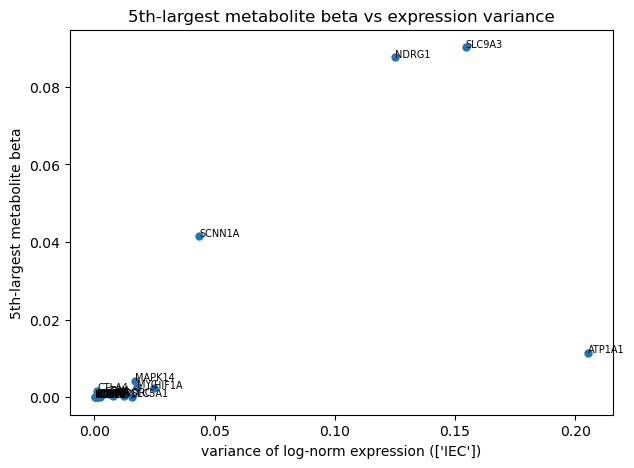

,gene,beta_stat,variance,n_active
0,SLC9A3,9.021463e-02,0.154394,88
1,NDRG1,8.763464e-02,0.125180,88
2,SCNN1A,4.157940e-02,0.043593,86
3,ATP1A1,1.149766e-02,0.205330,88
4,MAPK14,4.223100e-03,0.017009,83
5,MYC,2.659887e-03,0.017656,79
6,HIF1A,2.266125e-03,0.024943,82
7,CTLA4,1.703201e-03,0.001136,76
8,TOX,9.206455e-04,0.006092,48
9,SGK1,7.372224e-04,0.004064,49


In [28]:
# Example: 5th-largest metabolite beta per gene vs that gene's expression variance (IEC).
# Pass percentile=90 (etc.) to rank by a percentile of the betas instead of a fixed k.
topk_beta_vs_variance(dfs, adata, TIER, cell_types=[CELL_TYPE], k=5)
# topk_beta_vs_variance(dfs, adata, TIER, cell_types=[CELL_TYPE], percentile=90)

## All samples\n\nThe last plot (k-th largest metabolite beta vs gene-expression variance) run across **every** registered sample. Reads each adata from disk on demand; edit `SAMPLES` at the top to change the set.

In [ ]:
# The last plot's logic (topk_beta_vs_variance) run across every registered sample, one panel
# each. For each sample we load its adata + its own harreman CSV, rebuild `dfs` exactly like the
# single-sample path (extract_betas), then reuse topk_beta_vs_variance(..., plot=False) -- so the
# metric is identical to the single-sample plot above, just faceted and labelled by sample.
def plot_topk_all_samples(tier, cell_types=None, k=5, percentile=None, samples=None, ncols=2):
    samples = SAMPLES if samples is None else samples          # read current registry, not a stale bind
    label = f'{percentile}th-pct metab beta' if percentile is not None else f'{k}th-largest metab beta'
    ct = _ct_label(cell_types)
    n = len(samples); nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
    axes = axes.ravel()
    for ax, name in zip(axes, samples):
        ad = load_sample_adata(name)
        n_ct = ad.n_obs if cell_types is None else int(ad.obs[tier].isin(cell_types).sum())
        if n_ct == 0:                                          # this slice has none of these cell types
            ax.set_title(f'{name}: no {ct}'); ax.axis('off'); del ad; continue
        harr = pd.read_csv(f'{sample_dir(name)}/easy_download/harreman_outputs/[ccc_results][cell_com_df_m].csv')
        dfs = {g: extract_betas(g, ad, harr, tier, cell_types) for g in ad.uns['beta_modulators']}
        df = topk_beta_vs_variance(dfs, ad, tier, cell_types=cell_types, k=k, percentile=percentile, plot=False)
        ax.scatter(df['variance'], df['beta_stat'], s=25)
        for _, r in df.iterrows():
            ax.annotate(r['gene'], (r['variance'], r['beta_stat']), fontsize=7)
        ax.set_title(f'{name}  (n={n_ct} {ct})')
        ax.set_xlabel(f'variance of log-norm expr ({ct})'); ax.set_ylabel(label)
        del ad
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle(f'{label} vs expression variance across samples ({ct})')
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [ ]:
# The last plot, across all four slices. Uses the notebook's TIER/CELL_TYPE settings.
plot_topk_all_samples(TIER, cell_types=[CELL_TYPE], k=5)
# percentile instead of k:  plot_topk_all_samples(TIER, cell_types=[CELL_TYPE], percentile=90)